# Zomato Restaurant Data Analysis

## Project Overview

This project analyzes restaurant data from Zomato to understand customer preferences, restaurant popularity, spending patterns, and rating trends.

The analysis uses Python, Pandas, Matplotlib, and Seaborn to clean the data, visualize patterns, and generate business insights that could help improve customer experience and restaurant recommendations.

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df = pd.read_csv("/Users/vidhigadge/machine learning projects /Zomato data analysis/Zomato data .csv")

In [3]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [4]:
df.isnull().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

In [9]:
#convert the data type of rating 
def handleRate(value):
    value= str(value).split('/')
    value = value[0];
    return float(value)
df['rate'] = df['rate'].apply(handleRate)


In [10]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [52]:
# Average rating by restaurant type
avg_rating_by_type = df.groupby('listed_in(type)')['rate'].mean().sort_values(ascending=False)

In [48]:
# Online vs offline average rating
df.groupby('online_order')['rate'].mean()

online_order
No     3.487778
Yes    3.858621
Name: rate, dtype: float64

In [49]:
# Average cost by restaurant type
df.groupby('listed_in(type)')['approx_cost(for two people)'].mean().sort_values(ascending=False)

listed_in(type)
Buffet    671.428571
other     668.750000
Cafes     545.652174
Dining    357.272727
Name: approx_cost(for two people), dtype: float64

In [50]:
# Top 10 restaurants by votes
df[['name', 'votes', 'rate']].sort_values(by='votes', ascending=False).head(10)

,name,votes,rate
38,Empire Restaurant,4884,4.4
86,Meghana Foods,4401,4.4
7,Onesta,2556,4.6
44,Onesta,2556,4.6
65,Kabab Magic,1720,4.1
37,Szechuan Dragon,1647,4.2
54,Roving Feast,1047,4.0
14,San Churro Cafe,918,3.8
2,San Churro Cafe,918,3.8
67,Gustoes Beer House,868,4.1


## Question 1: Which restaurant type is most common?

Understanding the most popular restaurant category helps businesses focus their marketing efforts and allocate resources effectively.

In [ ]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


Text(0.5, 0, 'Type of restaurant')

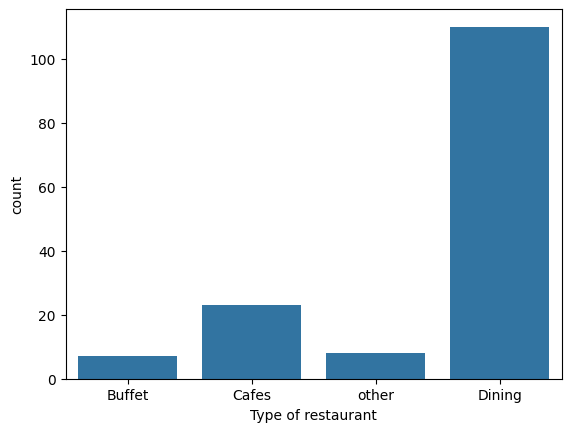

In [15]:
sns.countplot(x = df['listed_in(type)'])
plt.xlabel("Type of restaurant")

Dining restaurants are the most common restaurant category on Zomato.

This indicates that customers prefer traditional dine-in experiences compared to other restaurant types.

## Question 2: Which restaurant type has received the highest number of customer votes?

Customer votes indicate popularity and engagement with restaurants.

In [ ]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


Text(0, 0.5, 'votes')

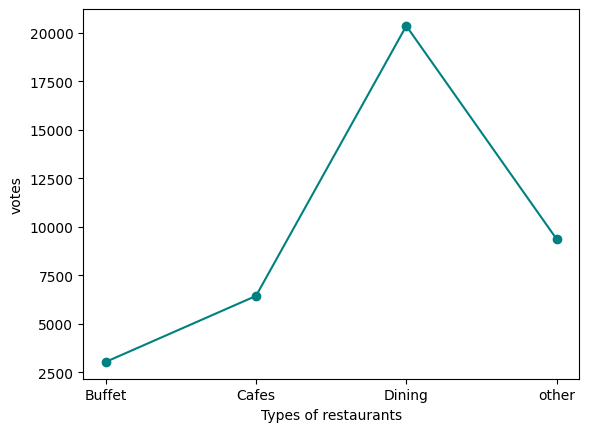

In [24]:
grouped_data = df.groupby('listed_in(type)')['votes'].sum()
result = pd.DataFrame({'votes' : grouped_data})
plt.plot(result, c="teal", marker='o')
plt.xlabel("Types of restaurants")
plt.ylabel("votes")

Dining restaurants received the highest number of customer votes, indicating higher customer interaction and popularity.

## Question 3: What ratings do most restaurants receive?

Analyzing ratings helps understand the overall quality of restaurants available on the platform.

Text(0.5, 1.0, 'Rating Distribution')

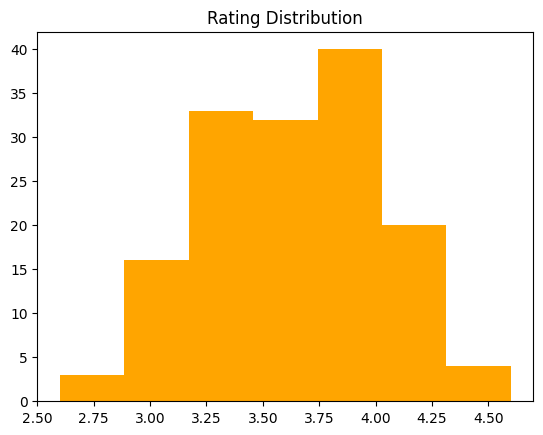

In [40]:
# ratings
plt.hist(df["rate"], bins=7, color="orange")
plt.title("Rating Distribution")

Most restaurants have ratings between **3.5 and 4.0**, suggesting that the majority maintain good customer satisfaction.

## Question 4

### What is the average spending of couples who order online?

Approximate cost for two people is used as an estimate of average spending by couples.

In [ ]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


/var/folders/5b/j57kqnxd4bz_fkwb7nygjb600000gn/T/ipykernel_1663/270665298.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=couple_data, palette='husl')


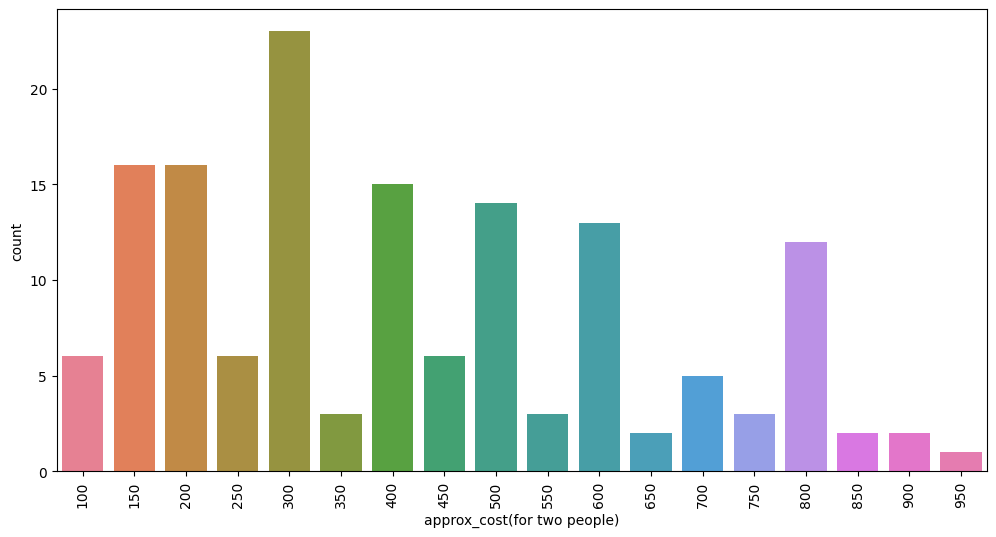

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

couple_data = df["approx_cost(for two people)"]

plt.figure(figsize=(12,6))
sns.countplot(x=couple_data, palette='husl')
plt.xticks(rotation=90)
plt.show()


Most couples spend approximately **₹300** per order, making it one of the most common spending ranges.

## Question 5: Which ordering mode receives better ratings?

Comparing online and offline orders helps understand customer satisfaction across different ordering methods.

In [ ]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


<Axes: xlabel='online_order', ylabel='rate'>

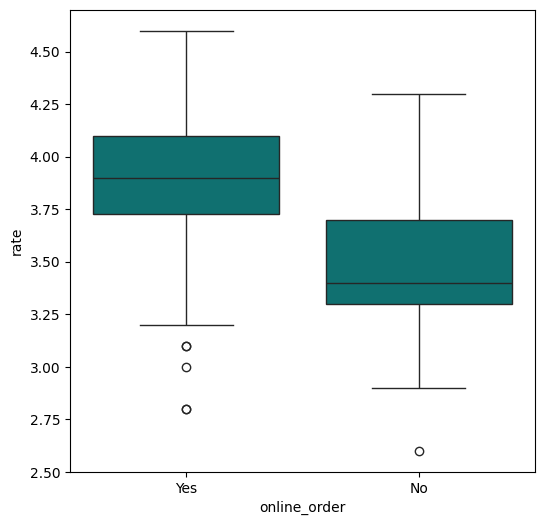

In [44]:
plt.figure(figsize=(6,6))
sns.boxplot(x = 'online_order', y = 'rate', data = df,color="teal" )

Restaurants accepting online orders generally receive higher average ratings than restaurants that only provide offline ordering.

## Question 6: Which restaurant type receives more offline orders?

Identifying restaurant categories with stronger offline demand can help Zomato design targeted promotional campaigns.

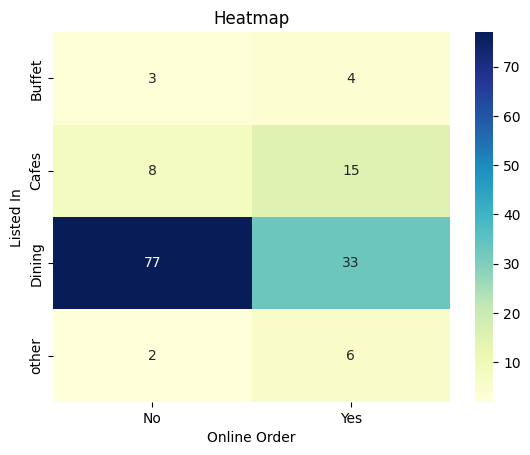

In [46]:
pivot_table = df.pivot_table(index = 'listed_in(type)', columns = 'online_order', aggfunc = 'size', fill_value=0)
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu", fmt='d')
plt.title("Heatmap")
plt.xlabel("Online Order")
plt.ylabel("Listed In")
plt.show() 

Dining restaurants receive a larger proportion of offline orders compared to other restaurant categories.

## Question 7: Which restaurant categories receive the highest average customer ratings?

Understanding average ratings across restaurant types helps identify which categories provide better customer experiences and may deserve greater visibility on the platform.

/var/folders/5b/j57kqnxd4bz_fkwb7nygjb600000gn/T/ipykernel_1663/926738139.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_rating_by_type.index, y=avg_rating_by_type.values, palette="magma")


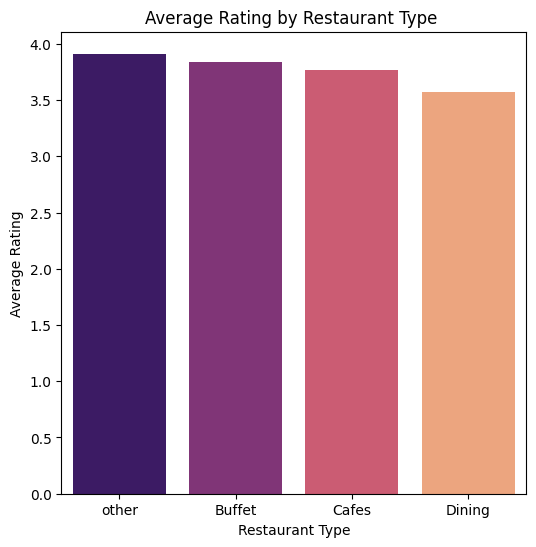

In [55]:
plt.figure(figsize = (6,6))
sns.barplot(x=avg_rating_by_type.index, y=avg_rating_by_type.values, palette="magma")
plt.title("Average Rating by Restaurant Type ")
plt.xlabel("Restaurant Type")
plt.ylabel("Average Rating")
#plt.xticks(rotation =90)
plt.show()

The chart shows that **Other** restaurant categories have the highest average customer rating (approximately **3.9**), followed by **Buffet** and **Cafes**.

**Dining** restaurants have the lowest average rating (around **3.6**).

Although Dining restaurants are the most common on the platform, they receive comparatively lower average ratings. This may indicate greater variation in service quality or higher customer expectations due to their popularity.

In [58]:
restaurant_summary = (df.groupby('listed_in(type)').agg
        (Average_Rating=('rate', 'mean'),
          Number_of_Restaurants=('name', 'count'),
          Average_Votes=('votes', 'mean')
        ).sort_values(by='Average_Rating', ascending=False))



In [59]:
restaurant_summary

,Average_Rating,Number_of_Restaurants,Average_Votes
listed_in(type),,,
other,3.912500,8,1170.875000
Buffet,3.842857,7,432.571429
Cafes,3.765217,23,279.739130
Dining,3.571818,110,185.118182


### Relationship between cost and ratings

## Question 8: Do expensive restaurants receive higher customer ratings?

This analysis checks whether restaurants with a higher approximate cost for two people also tend to have higher ratings.

In [60]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [61]:
cost_rating_df = df[['approx_cost(for two people)','rate']].copy()

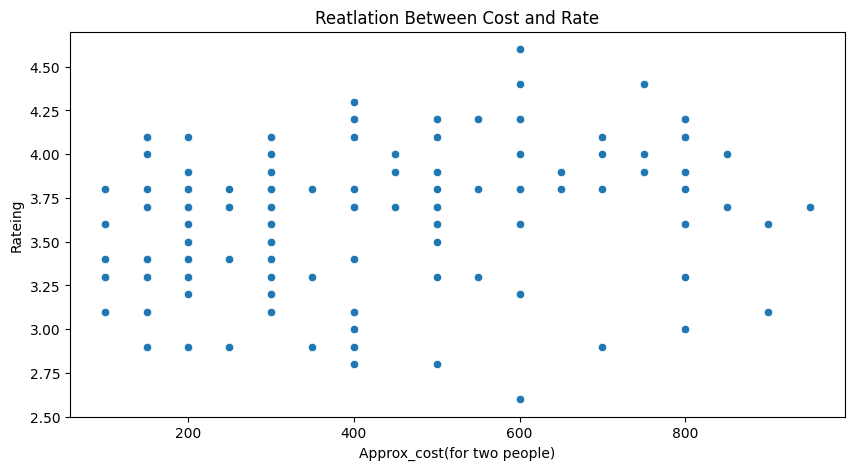

In [67]:
plt.figure(figsize=(10,5))
sns.scatterplot(data = cost_rating_df,
               x='approx_cost(for two people)',
               y='rate')
plt.title('Reatlation Between Cost and Rate')
plt.xlabel("Approx_cost(for two people)")
plt.ylabel("Rateing")
plt.show()

The scatter plot does not show a strong relationship between restaurant cost and customer ratings.

Restaurants across different price ranges receive both high and low ratings, indicating that higher prices do not necessarily lead to better customer satisfaction.

This suggests that factors such as food quality, service, and overall dining experience have a greater influence on customer ratings than price alone.

In [65]:
correlation = cost_rating_df['approx_cost(for two people)'].corr(cost_rating_df['rate'])

print("Correlation between cost and rating:", round(correlation, 2))

Correlation between cost and rating: 0.28


The correlation value supports the conclusion of the graph. 0.28 shows that there is weak positive correlation between cost and rating. 

## Question 9: Top 10 Most Popular Restaurants

Restaurants are ranked according to customer votes.

In [68]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


In [69]:
top_restaurants = df[['name', 'votes', 'rate']]

top_restaurants.head()

,name,votes,rate
0,Jalsa,775,4.1
1,Spice Elephant,787,4.1
2,San Churro Cafe,918,3.8
3,Addhuri Udupi Bhojana,88,3.7
4,Grand Village,166,3.8


In [ ]:
top_restaurants = top_restaurants.sort_values(
    by='votes',
    ascending=False
)

top_restaurants.head()

,name,votes,rate
38,Empire Restaurant,4884,4.4
86,Meghana Foods,4401,4.4
7,Onesta,2556,4.6
44,Onesta,2556,4.6
65,Kabab Magic,1720,4.1


In [71]:
top10 = top_restaurants.head(10)

/var/folders/5b/j57kqnxd4bz_fkwb7nygjb600000gn/T/ipykernel_1663/33745998.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


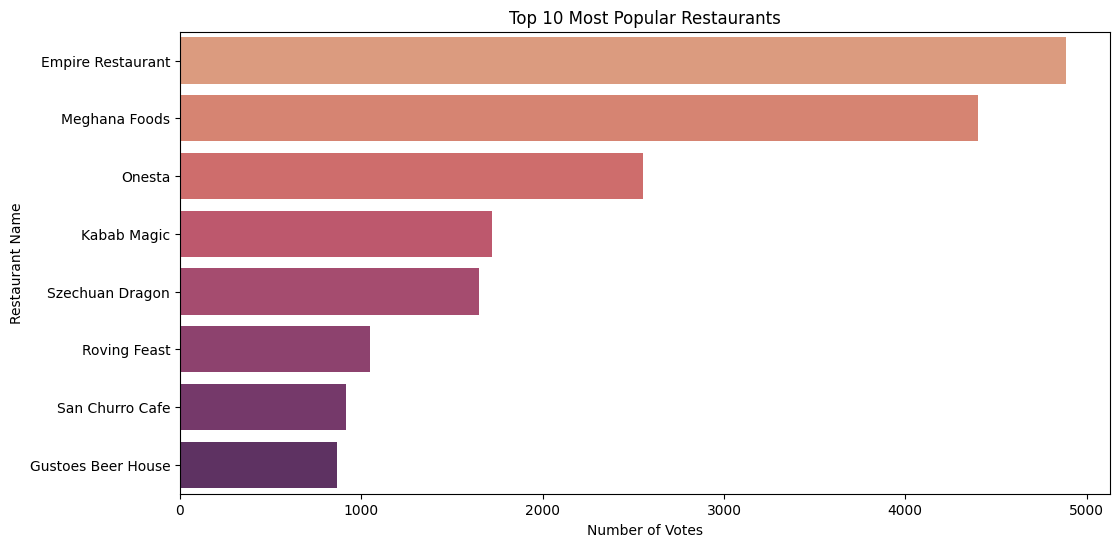

In [76]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x='votes',
    y='name',palette="flare"
)

plt.title("Top 10 Most Popular Restaurants")
plt.xlabel("Number of Votes")
plt.ylabel("Restaurant Name")

plt.show()

# Business Recommendations

Based on the analysis of the Zomato restaurant dataset, the following recommendations are proposed:

### 1. Promote Highly Rated Restaurants
Restaurants with consistently high customer ratings should be featured more prominently on the platform through recommendations, featured listings, and promotional campaigns. This can improve customer satisfaction and increase user engagement.

### 2. Improve the Dining Restaurant Experience
Although dining restaurants are the most common and receive the highest number of customer votes, they have comparatively lower average ratings than some other restaurant categories. Zomato can work with these restaurants to improve service quality, food consistency, and customer experience.

### 3. Encourage Online Ordering
The analysis indicates that restaurants offering online ordering generally receive better customer ratings. Encouraging more restaurants to provide online ordering could improve convenience for customers and increase overall platform engagement.

### 4. Focus on Value Rather Than Price
The relationship between restaurant cost and customer ratings appears to be weak. This suggests that customers value food quality, service, and overall experience more than price alone. Restaurants should focus on delivering consistent value rather than simply increasing prices.

### 5. Partner with Popular Restaurants
Restaurants with a high number of customer votes demonstrate strong customer trust and engagement. Forming partnerships with these restaurants for exclusive offers and promotions could increase traffic and customer retention.

### 6. Use Data-Driven Recommendations
Restaurant recommendations should consider multiple factors such as customer ratings, number of votes, restaurant type, and online ordering availability rather than relying on a single metric. This would provide users with more personalized and relevant restaurant suggestions.

# Conclusion

This project explored restaurant data from Zomato using Python to identify trends in customer preferences, restaurant popularity, spending patterns, and customer satisfaction.

### Key Findings

- Dining restaurants are the most common restaurant type on the platform.
- Dining restaurants receive the highest number of customer votes, indicating strong customer engagement.
- Most restaurant ratings fall between **3.5 and 4.0**, suggesting generally positive customer experiences.
- The average spending for two people is approximately **₹300**.
- Restaurants offering online ordering tend to receive higher customer ratings.
- Restaurant cost has only a weak relationship with customer ratings, indicating that customers prioritize quality and overall experience over price.

Overall, this analysis demonstrates how exploratory data analysis (EDA) can uncover meaningful business insights that support better decision-making for restaurant discovery platforms like Zomato.